# Amazon Sales Data - Exploratory Data Analysis (EDA)
Bu notebook, ML ile Dinamik Risk ajanımızın temelini olusturacak veriyi anlamlandirmak icin dizayn edilmistir. Orijinal veriye MÜDAHALE EDILMEDEN (read_csv) analizler kurgulanir.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# Veri okunuyor (Sadece Read)
df = pd.read_csv('../database/Amazon Sale Report.csv', low_memory=False)
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


## 1. Veri Kalitesi ve Eksiklik Analizi
Hangi sütunların modeli zehirleyebilecegine ve NaN oranlarina bakalim.

In [2]:
df.info()
print('\n--- Eksik Veri Oranlari (%) ---')
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

<class 'pandas.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  str    
 2   Date                128975 non-null  str    
 3   Status              128975 non-null  str    
 4   Fulfilment          128975 non-null  str    
 5   Sales Channel       128975 non-null  str    
 6   ship-service-level  128975 non-null  str    
 7   Style               128975 non-null  str    
 8   SKU                 128975 non-null  str    
 9   Category            128975 non-null  str    
 10  Size                128975 non-null  str    
 11  ASIN                128975 non-null  str    
 12  Courier Status      122103 non-null  str    
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  str    
 15  Amount              121180 non-null  float64


## 2. Kategori Çözümlemesi (Status)
Satış başarısı ve Amazon daki genel Status dagilimini gormek (Ornegin Cancelled satislari Demand oranina eklemeli miyiz?)

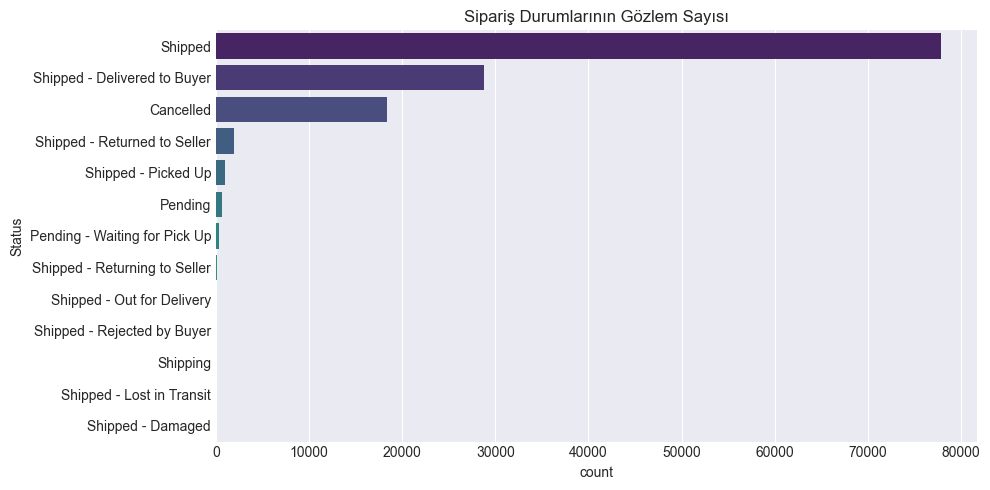

In [3]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='Status', order=df['Status'].value_counts().index, palette='viridis')
plt.title('Sipariş Durumlarının Gözlem Sayısı')
plt.tight_layout()
plt.show()

## 3. Zaman Serisi Dağılımı (Trend)
Verinin LSTM, XGBoost veya Prophet ile Demand Forecasting e uygunlugu icin Tarihleri kontrol edelim.

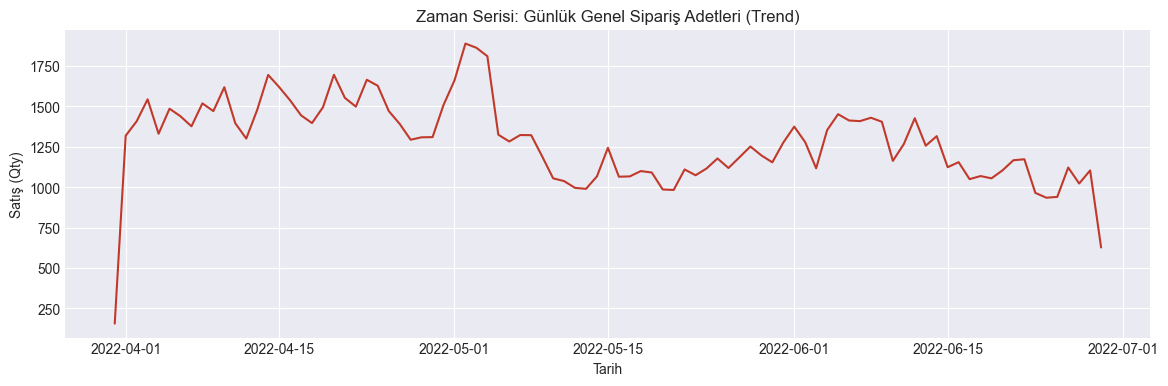

In [4]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
daily_demand = df.groupby('Date')['Qty'].sum().reset_index()

plt.figure(figsize=(14,4))
sns.lineplot(data=daily_demand, x='Date', y='Qty', color='#c0392b')
plt.title('Zaman Serisi: Günlük Genel Sipariş Adetleri (Trend)')
plt.ylabel('Satış (Qty)')
plt.xlabel('Tarih')
plt.show()

**🔬 Makine Öğrenmesi Mimari Tercihi (LSTM vs XGBoost):**

Yukarıdaki zaman serisi grafiğine (Trend) dikkatle bakıldığında, sipariş hacimlerinin oldukça **"seyrek" (intermittent)** ve öngörülemez patlamalarla (spikes) dolu olduğu görülmektedir.

1. **Deep Learning (LSTM / RNN) Neden Uygun Değil?**
   - LSTM gibi derin öğrenme (Deep Learning) modelleri, uzun dönemli hafıza gerektiren kesintisiz, yoğun (dense) ve yüksek otokorelasyona sahip verilerde (Örn: Borsa fiyatları, sıcaklık verileri) çok başarılıdır. Ancak Amazon e-ticaret satışlarında olduğu gibi **sıfır-enflasyonlu (zero-inflated)** (ürünün günlerce hiç satmadığı) ve ani talep patlamalarının (kampanyalar vs.) yaşandığı verilerde **aşırı öğrenme (overfitting)** yaşar veya ağırlıkları sıfıra yaklaşarak modelin felç olmasına (vanishing gradients) yol açabilir.

2. **Ağaç Tabanlı Modeller (XGBoost / LightGBM) Neden Daha İyi?**
   - Karar ağaçları tabanlı (Tree-based) algoritmalar, bu tür kesintili ve seyrek verileri sınıflandırma veya karar sınırları (decision boundaries) çizerek öğrenir. Sıfır satış günlerini "boşluk" olarak değil, bir "karar durumu" olarak kodlar.
   - Eklediğimiz *`lag_7`*, *`lag_30`*, ve özellikle *`velocity_ratio`* gibi çıkarımlı özellikler (Feature Engineering), XGBoost'un ani satış patlamalarını ve pazar dinamiklerini (örneğin son 1 haftanın ivmesi) bir insan beyni gibi kavramasını sağlar. Lineer modeller bu sivri uçlarda (spikes) çökerken, XGBoost (özellikle Quantile hedef fonksiyonu ile donatıldığında) P10/P50/P90 bantlarıyla bu kaotik veriyi başarıyla kontrol altına alır.


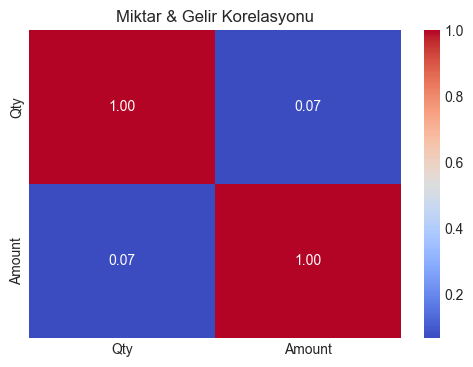

In [5]:
# Amount ve Qty Korelasyonuna Isı Haritasi (Heatmap) Yaklasimi
numeric_cols = ['Qty', 'Amount']
fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
plt.title('Miktar & Gelir Korelasyonu')
plt.show()